<a href="https://colab.research.google.com/github/paavanikondeti/Pneumonia-Detection-Using-Chest-XRay/blob/main/Wine_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


TASK 1: Load and Understand the Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
%matplotlib inline

In [2]:
import os
for root, dirs, files in os.walk("/"):
    if "winequality.csv" in files:
        print(os.path.join(root, "winequality.csv"))

/winequality.csv


In [3]:
df = pd.read_csv("/winequality.csv")

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [6]:
df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
194,7.6,0.55,0.21,2.2,0.071,7.0,28.0,0.99640,3.28,0.55,9.7,5
790,7.4,0.37,0.43,2.6,0.082,18.0,82.0,0.99708,3.33,0.68,9.7,6
1124,6.5,0.58,0.00,2.2,0.096,3.0,13.0,0.99557,3.62,0.62,11.5,4
406,9.8,0.44,0.47,2.5,0.063,9.0,28.0,0.99810,3.24,0.65,10.8,6
1301,6.7,0.86,0.07,2.0,0.100,20.0,57.0,0.99598,3.60,0.74,11.7,6


What type of data is present in the dataset?

The dataset contains structured numerical data.
All the input features are numerical values that represent different chemical properties of wine, such as acidity, sugar content, and alcohol level.
This type of data is suitable for applying machine learning algorithms.

What does each row represent?

Each row in the dataset represents one individual wine sample.
The values in that row describe the chemical composition of that wine, and the quality column represents the quality score assigned to that specific wine sample.

TASK 2: Basic Data Inspection


In [7]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

What are the column names in the dataset?

The dataset contains the following columns:fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality


In [8]:
df.shape

(1599, 12)

How many rows and columns are there in the dataset?

The dataset contains 1599 rows and 12 columns.

In [9]:
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


What is the data type of each column in the dataset?

All the input feature columns in the dataset are of float (float64) data type,The quality column is of integer (int64) data type,

In [10]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


The summary statistics provide information such as mean, standard deviation, minimum, and maximum values for each feature.
This helps in understanding the distribution, range, and spread of the data before applying machine learning models.

Data inspection is important because it helps us understand the structure and quality of the dataset.
It allows us to identify data types, value ranges, and possible issues before training a machine learning model, which helps prevent errors and improves model performance.

TASK 3: Missing Values Analysis

In [11]:
df.isnull()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,False,False,False,False,False,False,False,False,False,False,False,False
1595,False,False,False,False,False,False,False,False,False,False,False,False
1596,False,False,False,False,False,False,False,False,False,False,False,False
1597,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


There are no missing values in the dataset, as all columns show a missing value count of zero.
If missing values were present in a real-world machine learning project, they could be handled using techniques such as:

Removing rows or columns with very few missing values

Filling missing values using mean, median, or mode

Using advanced methods like model-based or interpolation techniques

The choice of method depends on the amount of missing data and the type of feature.

TASK 4: Exploratory Data Analysis (EDA)

In [13]:
df['quality'].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


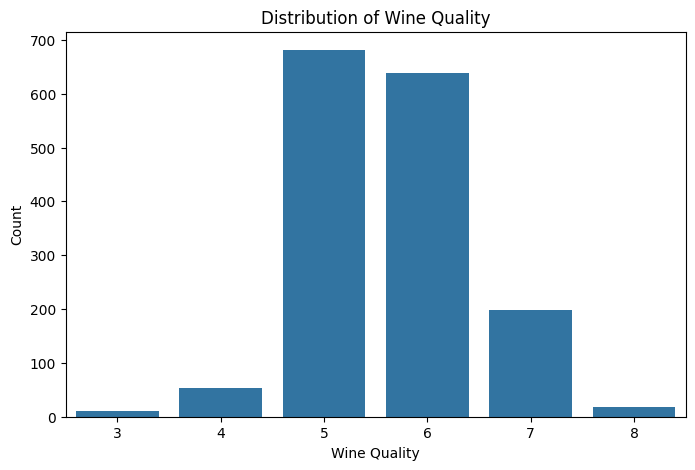

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=df)
plt.title("Distribution of Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Count")
plt.show()

What does this graph tell you about the dataset?
The graph shows that the wine quality data is not evenly distributed.
Most samples belong to medium quality categories, while high-quality wines are fewer in number.
This imbalance can affect model performance and must be considered during model training.

How does EDA help before model training?
EDA helps us understand data patterns, distributions, and potential problems such as imbalance or outliers.
It allows us to make informed decisions about feature engineering, model selection, and preprocessing before training machine learning models.

TASK 5: Convert the Problem into a Classification Task

In [15]:
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

In [16]:
df[['quality', 'quality_label']].head()

,quality,quality_label
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


In [17]:
df['quality_label'].value_counts()

,count
quality_label,
0,1382
1,217


Why is binary classification more useful than predicting exact quality scores in real-world systems?

Binary classification is more useful in real-world systems because it simplifies decision-making.
Instead of predicting exact quality scores, systems can easily classify wine as good or bad, which is more practical for businesses and customers.
It also reduces model complexity and improves prediction reliability.

TASK 6: Feature and Target Separation

In [18]:
X = df.drop(['quality', 'quality_label'], axis=1)

In [19]:
y = df['quality_label']

In [20]:
X.shape, y.shape

((1599, 11), (1599,))

Why should the original quality column not be used as an input feature?

After separating the dataset, the feature matrix X contains 1599 rows and 11 columns, and the target variable y contains 1599 values, confirming that the input features and target are properly separated.

The original quality column should not be used as an input feature because it is directly used to create the target variable quality_label.
Including it in the feature set would result in data leakage, where the model learns information it should not have during training, leading to unrealistically high accuracy and poor real-world performance.

TASK 7: Train–Test Split

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [23]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1279, 11), (320, 11), (1279,), (320,))

Why do we split data into training and testing sets?

We split the data into training and testing sets to evaluate how well the machine learning model performs on unseen data.
The training set is used to learn patterns, while the testing set is used to measure the model’s generalization ability.

What problem occurs if we train and test on the same data?

If the same data is used for both training and testing, the model may simply memorize the data instead of learning meaningful patterns.
This leads to overfitting and gives an unrealistic estimate of model performance.

After splitting, the training set contains 1279 samples with 11 features, and the testing set contains 320 samples with 11 features.
This confirms that an 80–20 split was correctly applied.

TASK 8: Feature Scaling


In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()

In [26]:
X_train_scaled = scaler.fit_transform(X_train)

In [27]:
X_test_scaled = scaler.transform(X_test)

In [28]:
X_train_scaled.shape, X_test_scaled.shape

((1279, 11), (320, 11))

Why is feature scaling important?

After applying feature scaling, the training data has 1279 samples with 11 features and the test data has 320 samples with 11 features, confirming that scaling was applied correctly without changing the data size.
Feature scaling is important because the features in the dataset have different ranges and units. Scaling brings all features to a similar scale so that no single feature dominates the learning process, which improves model performance and stability.

Which machine learning models need scaling and why?

Models such as Logistic Regression, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM) require feature scaling because they rely on distance calculations or gradient-based optimization.
Tree-based models like Decision Tree and Random Forest do not require feature scaling, as they split data based on feature thresholds rather than distances.


TASK 9: Model Training

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [30]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_accuracy

0.865625

Logistic Regression works by finding a linear boundary that separates the two classes.
It predicts the probability of a wine being good or bad using a logistic function.

In [31]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_accuracy

0.88125

KNN classifies a wine based on the majority class of its nearest neighbors.
It uses distance between data points, so feature scaling is important.

In [32]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)   # unscaled data is fine

y_pred_dt = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_accuracy

0.871875

A Decision Tree splits the data into branches based on feature values.
It makes decisions by learning simple if–else rules.

In [33]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)   # unscaled data is fine

y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_accuracy

0.9

Random Forest is an ensemble of multiple decision trees.
It improves accuracy and reduces overfitting by combining predictions from many trees.

In [34]:
svm = SVC()
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_accuracy

0.875

SVM works by finding the optimal hyperplane that best separates the two classes.
It is effective in high-dimensional spaces and requires feature scaling.

TASK 10: Model Evaluation and Comparison

In [35]:
print("Logistic Regression Accuracy:", lr_accuracy)
print("K-Nearest Neighbors Accuracy:", knn_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("Support Vector Machine Accuracy:", svm_accuracy)

Logistic Regression Accuracy: 0.865625
K-Nearest Neighbors Accuracy: 0.88125
Decision Tree Accuracy: 0.871875
Random Forest Accuracy: 0.9
Support Vector Machine Accuracy: 0.875


In [36]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine"
    ],
    "Accuracy": [
        lr_accuracy,
        knn_accuracy,
        dt_accuracy,
        rf_accuracy,
        svm_accuracy
    ]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.865625
1,K-Nearest Neighbors,0.881250
2,Decision Tree,0.871875
3,Random Forest,0.900000
4,Support Vector Machine,0.875000


Which model performed the best?

The Random Forest Classifier performed the best among all the trained models, achieving the highest accuracy of 90% on the test dataset.

Why do you think this model performed better on this dataset?

Random Forest performed better because it combines predictions from multiple decision trees, which helps capture complex patterns in the wine’s chemical properties.
It also reduces overfitting and handles feature interactions well, making it more accurate and robust for this dataset.

TASK 11: Pipeline and Hyperparameter Tuning

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

In [38]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

In [39]:
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

In [40]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             param_grid={'svm__C': [0.1, 1, 10],
                         'svm__kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [41]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'svm__C': 10, 'svm__kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.8944424019607844


Why are pipelines used in real-world Machine Learning systems?

Pipelines are used to combine data preprocessing and model training into a single, organized workflow.
They ensure that the same preprocessing steps, such as feature scaling, are applied consistently during training and testing, and they help prevent data leakage in real-world machine learning systems.

Why does hyperparameter tuning improve model performance?

Hyperparameter tuning improves model performance by finding the optimal values of model parameters.
Using GridSearchCV, different combinations of parameters are evaluated using cross-validation, and the best performing configuration is selected, which results in better and more reliable model performance.

Final Conclusion

In this project, a complete end-to-end machine learning system was developed to predict wine quality using chemical properties of wine.
The dataset was first explored to understand its structure, data types, and distribution, followed by missing value analysis and exploratory data analysis to gain meaningful insights.

The wine quality prediction problem was converted into a binary classification task to make it more practical for real-world applications.
Several machine learning models were trained and evaluated, including Logistic Regression, KNN, Decision Tree, Random Forest, and Support Vector Machine.

Among all models, the Random Forest Classifier achieved the highest accuracy of 90%, showing its ability to capture complex relationships between features.
Further improvement was achieved using a machine learning pipeline and hyperparameter tuning with GridSearchCV, which helped identify the optimal parameters for the SVM model.

This project helped in understanding how real-world machine learning systems are built, from data analysis to model optimization.
It demonstrates the importance of preprocessing, model comparison, and tuning in developing reliable and effective machine learning solutions.